<a href="https://colab.research.google.com/github/meldenkoh/DSAGang/blob/main/NUS_DSESC_DATABUSTERS_DSAGANG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1) Libraries Installation
##### The cell below is to help you keep track the libraries used and install them quickly.
##### Ensure the correct library names are used, and follow the syntax: **%pip install PACKAGE_NAME**.

## 2) Main Section for Code
### **ALL code for machine learning and dataset analysis** should be entered below.
##### Ensure that your code is clear and readable.
##### Remember to include comments and markdown notes as necessary to explain and highlight important segments of your code.

# New Section

In [ ]:
# Renee Cell
from google.colab import drive # Added 'import drive' to complete the import statement
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import scipy.stats as stats

file_path = "/content/drive/My Drive/Quarterly Data.csv"
data1 = pd.read_csv(file_path)

# Display the first few rows of data1
print(data1.head())

# Calculate GDP growth rate
data1['GDP_growth'] = np.append([np.nan], np.diff(data1['GDPC1']) / data1['GDPC1'].shift(1) * 100)

# Remove rows with missing data
data1 = data1.dropna()

# Replace NA values in GDPC1 with the column's mean value
data1['GDPC1'].fillna(data1['GDPC1'].mean(), inplace=True)

# Calculate GrowthRate (lagged GDP growth rate)
data1['GrowthRate'] = data1['GDPC1'] / data1['GDPC1'].shift(1) - 1

# Fit an autoregressive model (AR(1))
X = data1[['GDPC1']]  # Independent variable
X = sm.add_constant(X)  # Add a constant for the intercept
y = data1['GrowthRate']  # Dependent variable

model = sm.OLS(y, X).fit()  # Fit the model
print(model.summary())  # Print the summary
# In this case, the model explains only about 2% of the variance in the growth rate (R-squared = 0.02006),
# suggesting that GDP alone is not a strong predictor of growth rate, which is a relatively weak model.

# The p-value of 0.2218 indicates that the coefficient for GDPC1 is not statistically significant at typical significance levels (e.g., 0.05 or 0.01).
# This means we cannot reject the null hypothesis that GDPC1 has no impact on the GrowthRate. In simple terms, there is no significant evidence that GDPC1 (the lagged GDP) affects the growth rate of GDP in your model.

# Plot residuals and ACF of residuals
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(model.resid, marker='o', linestyle='-', color='b')
plt.title('Residuals of AR(1) Model')
plt.xlabel('Time')
plt.ylabel('Residuals')

plt.subplot(1, 2, 2)
plot_acf(model.resid, ax=plt.gca())
plt.title('ACF of Residuals')

plt.tight_layout()
plt.show()

# Durbin-Watson test for autocorrelation in residuals
dw_stat = durbin_watson(model.resid)
print(f'Durbin-Watson statistic: {dw_stat}')

# Q-Q plot for residuals
stats.probplot(model.resid, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.show()

# Add lagged values of GDPC1
data1['lag_GDPC1_2'] = data1['GDPC1'].shift(2)
data1['lag_GDPC1_3'] = data1['GDPC1'].shift(3)

# Fit a new model with additional lags (AR(3))
X2 = data1[['GDPC1', 'lag_GDPC1_2', 'lag_GDPC1_3']]  # Independent variables with lags
X2 = sm.add_constant(X2)  # Add constant for intercept
model2 = sm.OLS(y, X2).fit()  # Fit the model
print(model2.summary())  # Print the summary

# By adding additional lagged values of GDP (AR(3)), the model provides a more meaningful forecast as R squared increases,
# suggesting that past GDP data can be used to predict future growth more effectively.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     sasdate     GDPC1   PCECC96    PCDGx     PCESVx     PCNDx   GPDIC1  \
0    factors     0.000     0.000   1.0000     1.0000    1.0000    0.000   
1  transform     5.000     5.000   5.0000     5.0000    5.0000    5.000   
2   3/1/1959  3352.129  2039.017  68.6651  1374.1739  689.1172  354.894   
3   6/1/1959  3427.667  2070.508  71.2495  1394.7096  694.8197  382.500   
4   9/1/1959  3430.057  2092.138  72.6270  1413.6627  697.4699  357.798   

       FPIx  Y033RC1Q027SBEAx     PNFIx  ...  TNWMVBSNNCBBDIx   TLBSNNBx  \
0    0.0000            1.0000    1.0000  ...             0.00       0.00   
1    5.0000            5.0000    5.0000  ...             2.00       5.00   
2  357.0174           47.8021  171.0783  ...          1341.67  333245.24   
3  368.0640           49.2332  176.0004  ...          1294.15  345845.01   
4  371.9585           50.8372  180.7406 

ValueError: operands could not be broadcast together with shapes (264,) (265,) 

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Optimization terminated successfully.
         Current function value: 0.389820
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                T10YFFM   No. Observations:                  563
Model:                          Logit   Df Residuals:                      558
Method:                           MLE   Df Model:                            4
Date:                Tue, 11 Feb 2025   Pseudo R-squ.:                  0.2372
Time:                        10:41:44   Log-Likelihood:                -219.47
converged:                       True   LL-Null:                       -287.72
Covariance Type:            nonrobust   LLR p-value:                 1.582e-28
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

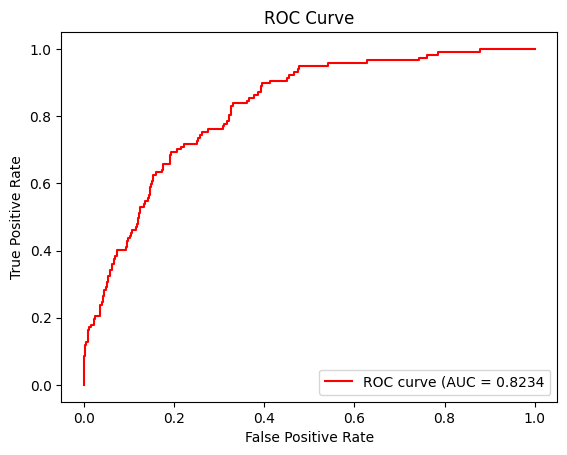

Confusion Matrix:
 [[300 146]
 [ 20  97]]
Accuracy: 70.515%
True Positive Rate (TPR): 0.829
False Positive Rate (FPR): 0.327
Precision: 0.399
False Negative Rate (FNR): 0.171


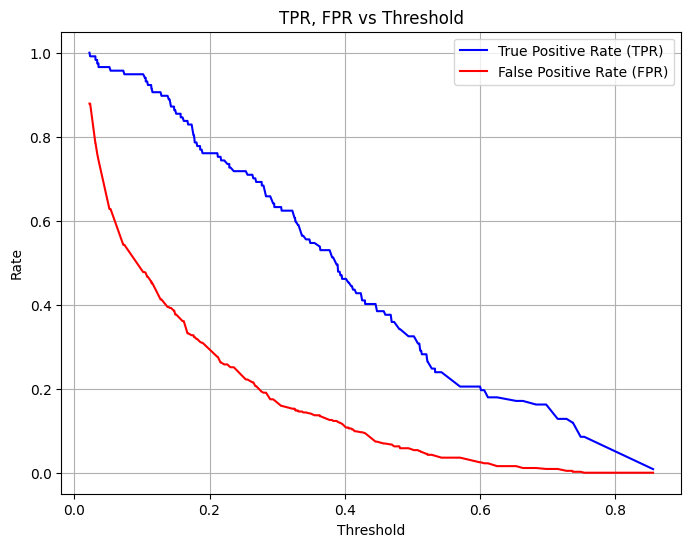

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Cross-validation scores: [0.94690265 0.77876106 0.56637168 0.75       0.76785714]
Mean cross-validation score: 0.7620


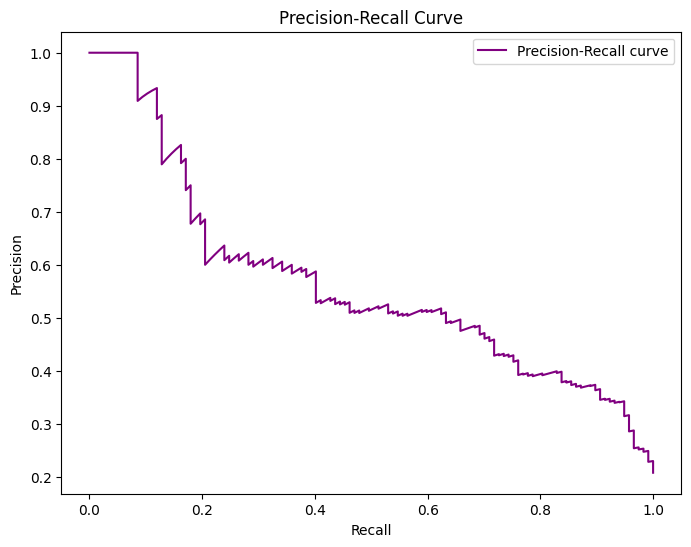

Average Precision Score: 0.5663


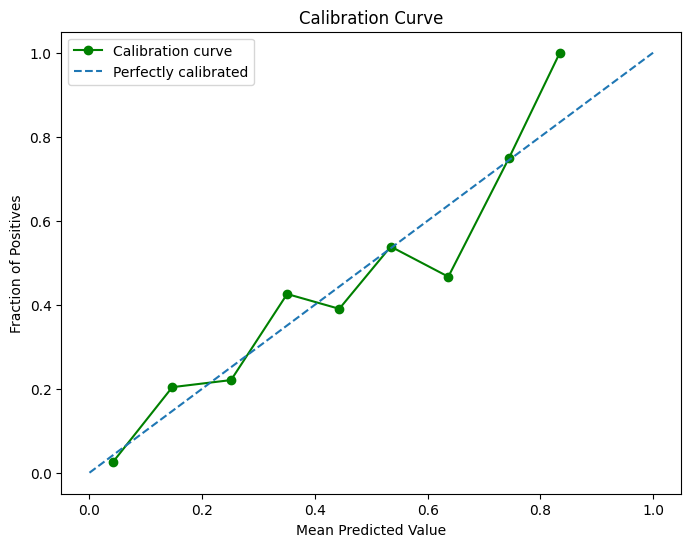

Log-Loss: 0.3904


In [ ]:
# Melden cell

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import roc_curve, auc, confusion_matrix

from google.colab import drive
# Mount Google Drive before attempting to read files from it
drive.mount('/content/drive')

file_path = "/content/drive/My Drive/Monthly Data.csv"
data = pd.read_csv(file_path)

 # There are many indicators that we can use to predict Economic Downturn, but our group zooms in on these 5
# 1. T10YFFM (10-Year Treasury Minus Fed Funds Rate)
 #Why it's used: The T10YFFM is often referred to as the yield curve or yield curve inversion indicator. A negative value (where the 10-year Treasury rate is lower than the Federal Funds Rate) is a strong signal of a recession,
 #as it implies that investors expect economic slowdowns. Yield curve inversions have historically preceded recessions, making it an essential indicator for predicting downturns.

 #2. HOUST (Housing Starts)
#Why it's used: Housing starts reflect the number of new homes being built. A decline in housing starts typically
 #signals a weak housing market, which is a common indicator of an economic slowdown or recession.
#Housing is a significant part of the economy, and when construction activity slows down,
 #it often reflects broader economic distress. Moreover, a weak housing market can affect consumer
 #confidence and spending, which could contribute to a recession.

  #3. UMCSENTx (University of Michigan Consumer Sentiment Index)
 #Why it's used: The UMCSENTx is a measure of consumer sentiment—essentially, how consumers feel about the current
 #state of the economy and their future expectations. When consumers are pessimistic or expect a downturn,
 #they are less likely to spend and invest. Low consumer sentiment is often correlated with economic slowdowns,
 #making this an important predictor of future economic activity.

 #4. MANEMP (Manufacturing Employment)
#Why it's used: Manufacturing employment tracks the number of people working in the manufacturing sector.
 #Manufacturing is a significant driver of economic activity, and shifts in employment levels in this sector
 #can indicate changes in the economy's strength. A decrease in manufacturing employment often suggests
 #declining demand for goods, which can signal a slowdown or a recession. Conversely, growth in manufacturing
 #employment typically indicates an expanding economy.

 #5. INDPRO (Industrial Production Index)
#Why it's used: The Industrial Production Index measures the total output of the industrial sector
 #(including manufacturing, mining, and utilities). A decline in industrial production is a common
 #indicator of an economic slowdown. When industrial production falls, it reflects reduced demand
 #for goods and services, which can point to a potential recession. Conversely, growth in industrial
 #production is often associated with economic expansion.

 # Hence, these are the indicators we chose to use for our analysis

 #Columns that we wish to analyse

# Selecting relevant columns
selected_columns = ["T10YFFM", "HOUST", "UMCSENTx", "MANEMP", "INDPRO"]
data = data[selected_columns]

# Remove first 229 rows (equivalent to tail(data, -229) in R)
data = data.iloc[229:].reset_index(drop=True)

# Create target variable (1 for recession, 0 for growth)
data["T10YFFM"] = (data["T10YFFM"] < 0).astype(int)


# Overall I am using T10YFFM (10-Year Treasury Minus Fed Funds Rate) – Measures yield curve inversion,
# a strong indicator for recession that our model will mainly focus on

# We are also considering Housing Starts (HOUST) as a weak housing market also signals economic slowdown

# We are also considering UMCSENTx which refers to the University of Michigan Consumer Sentiment Index
# as it surveys consumers' attitudes toward the current economic situation and their future expectations.

# We are also considering MANEMP stands for Manufacturing Employment. It is an economic indicator that
# tracks the number of people employed in the manufacturing sector.
#Manufacturing employment is a key economic indicator because changes in employment levels can signal shifts in economic conditions.
#Increasing employment in manufacturing typically indicates a growing economy with rising demand for goods,
#while declining employment suggests economic slowdown or automation replacing labor in certain
#manufacturing processes.

# Lastly, we are considering INDPRO stands for Industrial Production Index. It is an economic indicator that tracks the total output of the industrial sector in an economy,
#including manufacturing, mining, and utilities.
# It will be a useful indicator for us as ndustrial production is a key indicator of the health of the overall economy. Strong industrial production typically signals economic growth, as it shows businesses are producing more goods to meet demand.
#Declining industrial production can indicate a slowdown in economic activity,
#often signaling a recession or economic contraction.

# We shall build the model now to predict T10YFFM

# Combine all the columns into a new dataframe
X = sm.add_constant(data[["HOUST", "UMCSENTx", "MANEMP", "INDPRO"]])
y = data["T10YFFM"]

# Train logistic regression model using statsmodels
model = sm.Logit(y, X).fit()

# Display model summary (includes p-values)
print(model.summary())

# PR(>|Z|) for HOUST data is 0.425 and extremly large, hence We exclude this variable in our logstic model.

X = sm.add_constant(data[["UMCSENTx", "MANEMP", "INDPRO"]])
y = data["T10YFFM"]

# New logistic regression model
model_reduced = sm.Logit(y, X).fit()

# Display model summary (includes p-values)
print(model_reduced.summary())

# Predict probabilities
prob = model_reduced.predict(X)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y, prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='red', label=f'ROC curve (AUC = {roc_auc:.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Find optimal threshold (0.1735 in R code)
optimal_threshold = 0.1735
predicted_class = (prob > optimal_threshold).astype(int)

# Confusion Matrix
conf_ma = confusion_matrix(y, predicted_class)
print("Confusion Matrix:\n", conf_ma)

# Calculate Metrics
accuracy = np.trace(conf_ma) / np.sum(conf_ma) * 100
tpr_values = conf_ma[1, 1] / np.sum(conf_ma[1, :])
fpr_values = conf_ma[0, 1] / np.sum(conf_ma[0, :])
precision = conf_ma[1, 1] / np.sum(conf_ma[:, 1])
fnr = conf_ma[1, 0] / np.sum(conf_ma[1, :])

# Display Results
print(f"Accuracy: {accuracy:.3f}%")
print(f"True Positive Rate (TPR): {tpr_values:.3f}")
print(f"False Positive Rate (FPR): {fpr_values:.3f}")
print(f"Precision: {precision:.3f}")
print(f"False Negative Rate (FNR): {fnr:.3f}")

# Plot TPR, FPR, and Thresholds
plt.figure(figsize=(8, 6))
plt.plot(thresholds[:-1], tpr[:-1], label="True Positive Rate (TPR)", color='blue')  # Exclude last threshold value
plt.plot(thresholds[:-1], fpr[:-1], label="False Positive Rate (FPR)", color='red')  # Exclude last threshold value
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("TPR, FPR vs Threshold")
plt.legend()
plt.grid()
plt.show()


from sklearn.model_selection import cross_val_score

# Use Logistic Regression from sklearn for cross-validation
from sklearn.linear_model import LogisticRegression

# Create a logistic regression model
log_reg = LogisticRegression()

# Perform cross-validation (using 5 folds)
cross_val_scores = cross_val_score(log_reg, X.iloc[:, 1:], y, cv=5, scoring="accuracy")

print(f"Cross-validation scores: {cross_val_scores}")
print(f"Mean cross-validation score: {cross_val_scores.mean():.4f}")

#This means that OUR model achieves an average accuracy of 76.2% across the different folds of cross-validation, which is quite good!

# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, average_precision_score
precision, recall, _ = precision_recall_curve(y, prob)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='purple', label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()
avg_precision = average_precision_score(y, prob)
print(f"Average Precision Score: {avg_precision:.4f}")

#A Precision Score of 0.5663 indicates that when our model predicts a positive outcome (e.g., predicting a recession),
# it is correct about 56.63% of the time. In other words, for every 100 positive predictions our model makes,
#around 56.63 of them are true positives, and the remaining 43.37

# Calibration Curve
from sklearn.calibration import calibration_curve
fraction_of_positives, mean_predicted_value = calibration_curve(y, prob, n_bins=10)
plt.figure(figsize=(8, 6))
plt.plot(mean_predicted_value, fraction_of_positives, color='green', marker='o', label='Calibration curve')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
plt.xlabel('Mean Predicted Value')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
plt.show()

# Log-Loss
from sklearn.metrics import log_loss
log_loss_value = log_loss(y, prob)
print(f"Log-Loss: {log_loss_value:.4f}")

#A Log-Loss of 0.3904 suggests that our model is providing reasonably accurate probability estimates,
# but there’s still some room for improvement. 0.3904 is quite good, but lower values closer to 0 indicate
# better-calibrated probabilities. A Log-Loss of 0 indicates perfect calibration where the predicted probabilities
# exactly match the true probabilities.

# Areas for improvement!

# 1.Consider adding more informative features or using more complex models
# (e.g., ensemble methods like Random Forest or Gradient Boosting).

# 2. Hyperparameter tuning: Tuning the hyperparameters of your logistic regression or trying regularization methods
# (like L1 or L2 regularization) might help.
# 3. Calibration:
# We can try calibrating the predicted probabilities using methods like Platt Scaling or Isotonic Regression
# to make your model’s probabilities more reliable.
# 4. Cross-Validation:
#Ensure that our model is stable across different folds of cross-validation.
# If our model's performance varies greatly, we might want to address any issues related to overfitting or underfitting.

In [ ]:
#Gen cell
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from google.colab import drive # Added 'import drive' to complete the import statement
drive.mount('/content/drive')

# Load data
#monthly_data = pd.read_csv("/content/drive/My Drive/Monthly data.csv") # Changed file path
monthly_data = pd.read_csv("Monthly data.csv")
quarterly_data = pd.read_csv("Quarterly data.csv")
variable_data = pd.read_csv("Variable Description.csv", encoding="ISO-8859-1")


# Convert date columns to datetime format
monthly_data = monthly_data[pd.to_datetime(monthly_data["sasdate"], errors="coerce").notna()]
monthly_data["sasdate"] = pd.to_datetime(monthly_data["sasdate"], format="%m/%d/%Y", errors="coerce")
print(monthly_data.head())

quarterly_data = quarterly_data[pd.to_datetime(quarterly_data["sasdate"], errors="coerce").notna()]
quarterly_data["sasdate"] = pd.to_datetime(quarterly_data["sasdate"], format="%m/%d/%Y")

# GDP time series plot
plt.figure(figsize=(12,6))
plt.plot(quarterly_data["sasdate"], quarterly_data["GDPC1"], color="blue")
plt.title("Real GDP Over Time")
plt.xlabel("Year")
plt.ylabel("GDP (Billions)")
plt.grid()
plt.show()

# Highlight recession periods
recession_dates = [("2008-01-01", "2009-06-01"), ("2020-03-01", "2020-06-01")]
plt.figure(figsize=(12,6))
plt.plot(quarterly_data["sasdate"], quarterly_data["GDPC1"], color="blue")
for start, end in recession_dates:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color='gray', alpha=0.3)
plt.title("GDP with Recession Periods Highlighted")
plt.xlabel("Year")
plt.ylabel("GDP (Billions)")
plt.grid()
plt.show()

# Correlation matrix of key variables
key_vars = quarterly_data[["GDPC1", "PCECC96", "GPDIC1", "FPIx", "PNFIx", "CNCFx"]]
corr_matrix = key_vars.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Key Variables")
plt.show()

# Unemployment rate and economic contractions
plt.figure(figsize=(12,6))
plt.plot(quarterly_data["sasdate"], quarterly_data["UNRATE"], color="red")
plt.title("Unemployment Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.grid()
plt.show()

# Overlay GDP and Unemployment Rate
fig, ax1 = plt.subplots(figsize=(12,6))
ax1.plot(quarterly_data["sasdate"], quarterly_data["GDPC1"], color="blue", label="GDP")
ax2 = ax1.twinx()
ax2.plot(quarterly_data["sasdate"], quarterly_data["UNRATE"] * 1000, color="red", label="Unemployment Rate")
ax1.set_xlabel("Year")
ax1.set_ylabel("GDP (Billions)")
ax2.set_ylabel("Unemployment Rate (Scaled)")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("GDP vs. Unemployment Rate")
plt.grid()
plt.show()

# Inflation (CPI or PCE) vs. GDP
plt.figure(figsize=(12,6))
plt.plot(quarterly_data["sasdate"], quarterly_data["GDPC1"], color="blue", label="GDP")
plt.plot(quarterly_data["sasdate"], quarterly_data["PCECC96"], color="green", label="Inflation (PCE)")
plt.title("GDP vs. Inflation")
plt.xlabel("Year")
plt.ylabel("Scaled Values")
plt.legend()
plt.grid()
plt.show()

# Consumer Spending (PCECC96) Trends Before Contractions
plt.figure(figsize=(12,6))
plt.plot(quarterly_data["sasdate"], quarterly_data["PCECC96"], color="orange", label="Consumer Spending")
plt.plot(quarterly_data["sasdate"], quarterly_data["GDPC1"], color="blue", label="GDP")
plt.title("Consumer Spending Trends (PCECC96) vs. GDP")
plt.xlabel("Year")
plt.ylabel("Scaled Values")
plt.legend()
plt.grid()
plt.show()




ValueError: mount failed

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
#Fay Cell

#### Remember to rename your file name to **NUS_DSESC_DATABUSTERS_XX.ipynb** and ensure that it can run successfully. Good luck and have fun!